# Compute experiment data processing

This notebook:
- Creates a subdirectory in `analysis_plots` for each `compute_*.csv` in `measurements`, wipes and recreates them each run
- Copies each CSV into its subdirectory and adds derived columns
- **e** columns (e-prefixed): bound between -1 and +1
- **i** columns (i-prefixed): bound by ±5×IREFP (e.g. 500nA when IREFP=100nA)
- Plots and filters will be added back later.

In [15]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import shutil

def round_to_n_sig_figs(x, n=5):
    """Round scalar to n significant figures. Keeps 0, NaN, Inf unchanged."""
    if pd.isna(x) or x == 0 or np.isinf(x):
        return x
    try:
        return round(x, n - 1 - int(np.floor(np.log10(abs(x)))))
    except (ValueError, OverflowError):
        return x

def df_round_sig_figs(df, n=5):
    """Round all float columns to n significant figures (avoids 9.99...e-09 etc.)."""
    out = df.copy()
    for col in out.columns:
        if out[col].dtype.kind == 'f':
            out[col] = out[col].apply(lambda x: round_to_n_sig_figs(x, n))
    return out

# Absolute paths: same locations regardless of cwd (only .ipynb files stay in analysis_plots)
cwd = Path(os.getcwd()).resolve()
if cwd.name == 'analysis_plots':
    analysis_plots_dir = cwd
    measurements_dir = cwd.parent / 'measurements'
else:
    analysis_plots_dir = cwd / 'analysis_plots'
    measurements_dir = cwd / 'measurements'
analysis_plots_dir = analysis_plots_dir.resolve()
measurements_dir = measurements_dir.resolve()

print(f"analysis_plots_dir: {analysis_plots_dir}")
print(f"measurements_dir: {measurements_dir}")

# Step 1: Remove ALL compute_* subdirectories in analysis_plots (only notebooks remain)
if analysis_plots_dir.exists():
    for item in list(analysis_plots_dir.iterdir()):
        if item.is_dir() and item.name.startswith('compute_'):
            try:
                shutil.rmtree(item)
                print(f"Removed: {item.name}")
            except OSError as e:
                print(f"Warning: could not remove {item.name}: {e}")

# Step 2: Find compute CSVs in measurements
# If measurements/compute.csv exists, use ONLY that file; otherwise fall back to all compute_*.csv files
single_compute = measurements_dir / 'compute.csv'
if single_compute.exists():
    compute_csvs = [single_compute]
    print(f"Found 1 compute CSV (using only {single_compute.name}).")
else:
    compute_csvs = sorted(measurements_dir.glob('compute_*.csv'))
    print(f"Found {len(compute_csvs)} compute CSV(s): {[f.name for f in compute_csvs]}")

# Columns: value / IREFP, 3 decimal places
divide_by_irefp = ['KGAIN1', 'KGAIN2', 'TRIM1', 'TRIM2']
# Columns: A*2/IREFP - 1
linear_irefp = ['X1', 'X2', 'F11', 'F12', 'IMEAS']

processed_paths = []
for csv_path in compute_csvs:
    csv_path = csv_path.resolve()
    subdir_name = csv_path.stem  # e.g. compute_20260115_161903
    subdir = analysis_plots_dir / subdir_name
    subdir.mkdir(parents=True, exist_ok=True)
    dest_csv = subdir / csv_path.name
    shutil.copy2(str(csv_path), str(dest_csv))
    df = pd.read_csv(str(dest_csv))

    if 'IREFP' not in df.columns:
        print(f"  Skip {csv_path.name}: no IREFP column")
        continue
    irefp = df['IREFP'].replace(0, np.nan)

    for col in divide_by_irefp:
        if col in df.columns:
            df['e' + col] = (df[col] / irefp).round(3)

    for col in linear_irefp:
        if col in df.columns:
            df['e' + col] = df[col] * 2 / irefp - 1

    # Clip all e* columns to [-1, 1]
    e_cols = [c for c in df.columns if c.startswith('e')]
    for c in e_cols:
        df[c] = df[c].clip(-1.0, 1.0)

    # New formulas (row-wise)
    df['eXhat'] = df['eX1'] * df['eF11'] + df['eX2'] * df['eF12']
    df['eY'] = df['eIMEAS'] - df['eXhat']
    df['eXhatplus'] = df['eY'] * df['eKGAIN1'] + df['eXhat']
    df['iXhatplus'] = (df['eXhatplus'] + 1) * df['IREFP'] / 2

    # iDeltaX: if PPG_state is ERASE then iXhatplus - X1, else X1 - iXhatplus; minimum 1e-10
    is_erase = (df['PPG_state'] == 'ERASE')
    df['iDeltaX'] = np.where(is_erase, df['iXhatplus'] - df['X1'], df['X1'] - df['iXhatplus'])
    df['iDeltaX'] = df['iDeltaX'].clip(lower=1e-10)

    df['iOut1'] = df['X1'] * df['TRIM1'] / df['iDeltaX']

    # Clip all e* columns to [-1, 1]
    e_cols = [c for c in df.columns if c.startswith('e')]
    for c in e_cols:
        df[c] = df[c].clip(-1.0, 1.0)

    # Clip all i* columns to ±5*IREFP (per row, e.g. 500nA when IREFP=100nA)
    i_cols = [c for c in df.columns if c.startswith('i')]
    irefp_5 = 5.0 * df['IREFP']
    for c in i_cols:
        df[c] = df[c].clip(-irefp_5, irefp_5)

    # Round all floats to 5 significant figures (fixes 9.999...e-09 -> 1e-8 etc.)
    df = df_round_sig_figs(df, n=5)

    # Rename current columns for clarity
    rename_map = {}
    if 'OUT1_current' in df.columns:
        rename_map['OUT1_current'] = 'IOUT_meas'
    if 'iOut1' in df.columns:
        rename_map['iOut1'] = 'IOUT_sim'
    if rename_map:
        df = df.rename(columns=rename_map)

    # Move measured IOUT column to the end for readability
    if 'IOUT_meas' in df.columns:
        cols = [c for c in df.columns if c != 'IOUT_meas'] + ['IOUT_meas']
        df = df[cols]

    df.to_csv(str(dest_csv), index=False)
    processed_paths.append(dest_csv)
    print(f"  Created {subdir_name}/ and saved modified {csv_path.name}")

print(f"\nDone. Processed {len(processed_paths)} CSV(s).")
print("New columns: eKGAIN1, eKGAIN2, eTRIM1, eTRIM2, eX1, eX2, eF11, eF12, eIMEAS, eXhat, eY, eXhatplus, iXhatplus, iDeltaX, iOut1")

analysis_plots_dir: C:\Columbia\AdamResearch\kalman_2025\analysis_plots
measurements_dir: C:\Columbia\AdamResearch\kalman_2025\measurements
Found 1 compute CSV (using only compute.csv).
  Created compute/ and saved modified compute.csv

Done. Processed 1 CSV(s).
New columns: eKGAIN1, eKGAIN2, eTRIM1, eTRIM2, eX1, eX2, eF11, eF12, eIMEAS, eXhat, eY, eXhatplus, iXhatplus, iDeltaX, iOut1


In [9]:
# (Data filters removed — add back later)

In [10]:
# (Plot config removed — add back later)

In [11]:
# (Plot function removed — add back later)

In [12]:
# (Plot generation removed — add back later)

In [13]:
# iOut1 measurement report: counts by range (all points, no primary-axis filter)
# All processed datasets summarized in a single file.
# Categories: <1nA, 1nA–100nA, >100nA

NA_1 = 1e-9      # 1 nA
NA_100 = 100e-9  # 100 nA


def pct(x, n):
    return round_to_n_sig_figs(100 * x / n, 3) if n else 0


def make_report_row(values, dataset_name, series_type):
    values = values.astype(float)
    total = len(values)
    below_1na = (values < NA_1).sum()
    within_1na_100na = ((values >= NA_1) & (values <= NA_100)).sum()
    # All values above 100 nA (including >1 µA) are counted in above_100nA
    above_100na = (values > NA_100).sum()
    return {
        'dataset': dataset_name,
        'series_type': series_type,  # 'sim' or 'measured'
        'total': total,
        'below_1nA': below_1na,
        'within_1nA_to_100nA': within_1na_100na,
        'above_100nA': above_100na,
        'pct_below_1nA': pct(below_1na, total),
        'pct_within_1nA_100nA': pct(within_1na_100na, total),
        'pct_above_100nA': pct(above_100na, total),
    }


report_rows = []
for path in processed_paths:
    df = pd.read_csv(str(path))
    dataset_name = path.parent.name

    # Simulated values (IOUT_sim)
    if 'IOUT_sim' in df.columns:
        report_rows.append(make_report_row(df['IOUT_sim'], dataset_name, 'sim'))

    # Measured values (IOUT_meas)
    if 'IOUT_meas' in df.columns:
        report_rows.append(make_report_row(df['IOUT_meas'], dataset_name, 'measured'))

report_df = pd.DataFrame(report_rows)
report_path = analysis_plots_dir / 'iOut1_measurement_report.csv'
report_df.to_csv(str(report_path), index=False)
print(f"Report saved: {report_path}")
print(report_df.to_string(index=False))

Report saved: C:\Columbia\AdamResearch\kalman_2025\analysis_plots\iOut1_measurement_report.csv
dataset series_type  total  below_1nA  within_1nA_to_100nA  above_100nA  pct_below_1nA  pct_within_1nA_100nA  pct_above_100nA
compute         sim   3996         31                 1713         2252          0.776                  42.9             56.4
compute    measured   3996        149                 1820         2027          3.730                  45.5             50.7


Using dataset: compute (compute.csv)


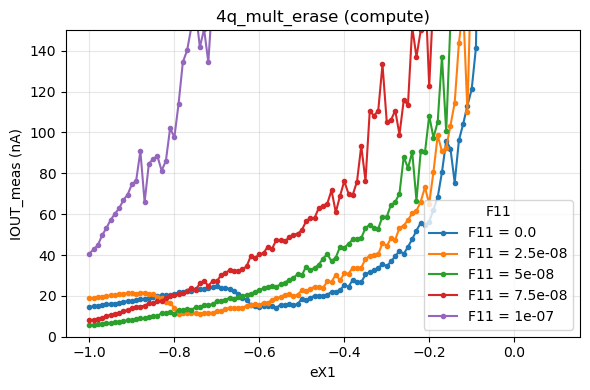

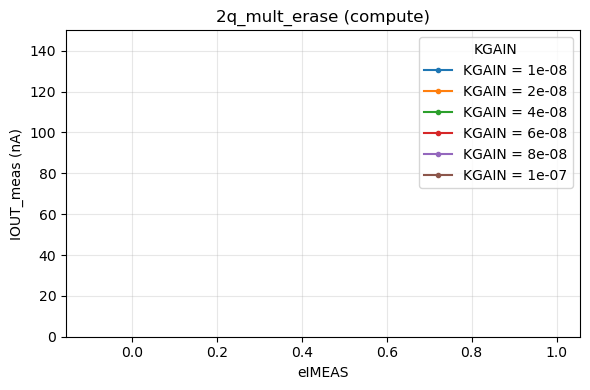

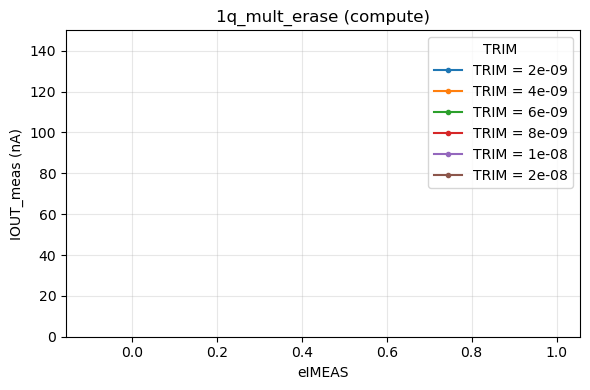

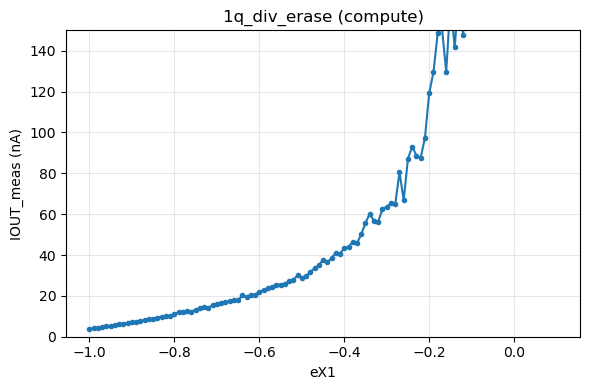

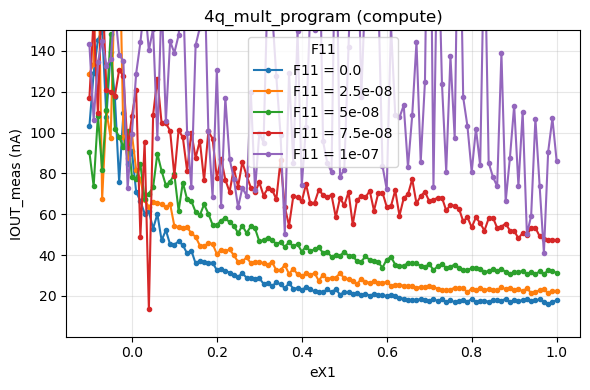

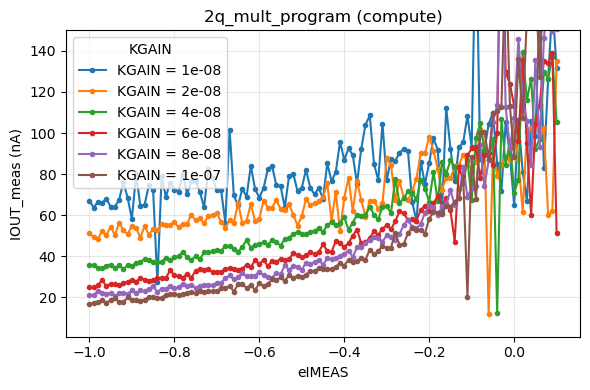

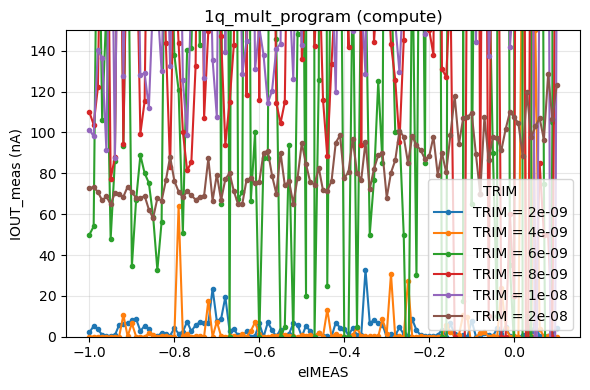

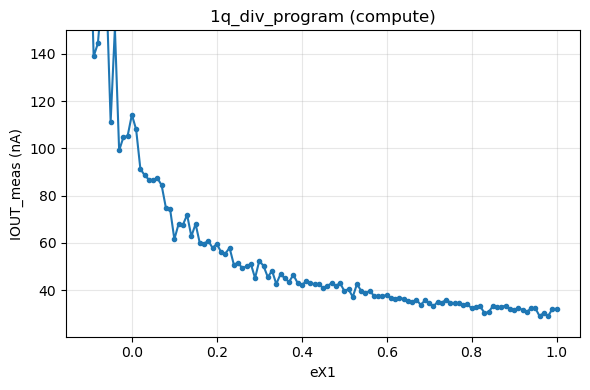

In [14]:
import matplotlib.pyplot as plt
import sys

# Ensure project root (parent of analysis_plots) is on sys.path so we can import configs
project_root = analysis_plots_dir.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from configs.compute_settings import EXPERIMENTS

# Plot settings
NA = 1e-9
Y_MAX_A = 100e-9  # 100 nA

if not processed_paths and not (analysis_plots_dir / "compute.csv").exists():
    print("No processed CSVs found to plot.")
else:
    # Prefer a consolidated compute.csv in analysis_plots if present; otherwise fall back to latest processed file
    preferred_path = analysis_plots_dir / "compute.csv"
    if preferred_path.exists():
        latest_path = preferred_path
        dataset_label = preferred_path.stem
        print(f"Using dataset: {dataset_label} ({preferred_path.name})")
    else:
        latest_path = processed_paths[-1]
        dataset_label = latest_path.parent.name
        print(f"Using dataset: {dataset_label} ({latest_path.name})")

    latest_df = pd.read_csv(str(latest_path))

    # Map abstract parameter names in sweep_variables to actual column names in the CSV
    # - KGAIN  -> KGAIN1 / eKGAIN1
    # - TRIM   -> TRIM1 / eTRIM1
    # - others -> use name as-is / e<name>
    def resolve_param_columns(param_name: str):
        if param_name == "KGAIN":
            base = "KGAIN1"
        elif param_name == "TRIM":
            base = "TRIM1"
        else:
            base = param_name
        e_col = f"e{base}"
        return base, e_col

    def plot_experiment(exp_cfg):
        name = exp_cfg.get("name", "<unnamed>")
        sweep_vars = exp_cfg.get("sweep_variables", []) or []
        if not sweep_vars:
            print(f"{name}: no sweep_variables defined, skipping.")
            return

        primary = sweep_vars[0]
        secondary = sweep_vars[1] if len(sweep_vars) > 1 else None

        df_exp = latest_df[latest_df["Experiment_Name"] == name].copy()
        if df_exp.empty:
            print(f"{name}: no rows found in {latest_path.name}, skipping.")
            return

        # X-axis: use e<primary> when available (e.g. eX1, eIMEAS, eKGAIN1, eTRIM1, etc.)
        primary_base, primary_e = resolve_param_columns(primary)
        if primary_e in df_exp.columns:
            x_col = primary_e
            x_label = primary_e
        elif primary_base in df_exp.columns:
            x_col = primary_base
            x_label = primary_base
        else:
            print(f"{name}: primary sweep '{primary}' not found in columns, skipping.")
            return

        df_exp = latest_df[latest_df["Experiment_Name"] == name].copy()
        if df_exp.empty:
            print(f"{name}: no rows found in {latest_path.name}, skipping.")
            return

        # X-axis: use e<primary> when available (e.g. eX1, eIMEAS, etc.)
        x_col_candidate = f"e{primary}"
        if x_col_candidate in df_exp.columns:
            x_col = x_col_candidate
            x_label = x_col
        elif primary in df_exp.columns:
            x_col = primary
            x_label = primary
        else:
            print(f"{name}: primary sweep '{primary}' not found in columns, skipping.")
            return

        # Y-axis: always measured OUT1 current in nA (linear scale 0–150 nA)
        if "IOUT_meas" in df_exp.columns:
            y_col = "IOUT_meas"
            y_label = "IOUT_meas (nA)"
        elif "OUT1_current" in df_exp.columns:
            # Fallback to original current column name if not yet renamed
            y_col = "OUT1_current"
            y_label = "OUT1_current (nA)"
        else:
            print(f"{name}: no measured output current column found, skipping.")
            return

        plt.figure(figsize=(6, 4))

        if secondary is None:
            # Single sweep variable: one curve
            plt.plot(
                df_exp[x_col],
                df_exp[y_col] / NA,
                marker=".",
                linestyle="-",
                label=name,
            )
        else:
            # Two sweep variables: primary on x-axis, secondary as separate curves
            secondary_base, secondary_e = resolve_param_columns(secondary)
            # Prefer grouping by normalized e* column when available,
            # but still label legend with the abstract name (e.g. F11, KGAIN, TRIM).
            if secondary_e in df_exp.columns:
                group_col = secondary_e
            elif secondary_base in df_exp.columns:
                group_col = secondary_base
            elif secondary in df_exp.columns:
                group_col = secondary
            else:
                print(f"{name}: secondary sweep '{secondary}' not found in columns, plotting single curve.")
                group_col = None

            if group_col is None:
                sec_groups = [(None, df_exp)]
            else:
                sec_groups = df_exp.groupby(group_col, sort=True)

            for sec_val, df_grp in sec_groups:
                label = f"{secondary} = {sec_val}" if sec_val is not None else name
                plt.plot(
                    df_grp[x_col],
                    df_grp[y_col] / NA,
                    marker=".",
                    linestyle="-",
                    label=label,
                )

        plt.xlabel(x_label)
        plt.ylabel(y_label)
        # Let matplotlib autoscale, then clamp within [0, 150 nA]
        y_min, y_max = plt.ylim()
        y_min_clamped = max(0, y_min)
        y_max_clamped = min(Y_MAX_A / NA, y_max)
        if y_max_clamped <= y_min_clamped:
            # Fallback to [0, 150 nA] if autoscale is degenerate
            y_min_clamped, y_max_clamped = 0, Y_MAX_A / NA
        plt.ylim(y_min_clamped, y_max_clamped)
        plt.title(f"{name} ({dataset_label})")
        if secondary is not None:
            plt.legend(title=secondary)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

    # Generate one plot per enabled experiment
    for exp_cfg in EXPERIMENTS:
        if not exp_cfg.get("enabled", True):
            continue
        plot_experiment(exp_cfg)